In [15]:
from langgraph import graph
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from dotenv import dotenv_values
from pydantic import BaseModel, Field
import os
import httpx
import operator

from batsman_workflow import initial_state

env_values = dotenv_values('.env')
if env_values.get('GROQ_API_KEY'):
    os.environ['GROQ_API_KEY'] = env_values['GROQ_API_KEY']

model_name = os.environ.get('GROQ_MODEL', 'openai/gpt-oss-20b')
http_client = httpx.Client(verify=False)
model = ChatGroq(
    model=model_name,
    temperature=0,
    api_key=os.environ.get('GROQ_API_KEY'),
    http_client=http_client
)


In [16]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay")
    score: float = Field(description="Score out of 10 for the essay", ge=0, le=10)

In [17]:
structured_model = model.with_structured_output(EvaluationSchema, method="json_schema")

In [18]:
essay = """
The Indian Constitution is the supreme law of India. It lays down the framework that defines the political principles, establishes the structure, procedures, powers, and duties of government institutions, and sets out fundamental rights and freedoms."""

In [19]:
prompt = f'Evaluate the following essay and provide feedback and a score out of 10:\n\n{essay}'
structured_model.invoke(prompt)

EvaluationSchema(feedback='The essay provides a concise overview of the Indian Constitution, highlighting its role as the supreme law, its framework for political principles, and its establishment of government structure, procedures, powers, and duties, as well as fundamental rights and freedoms. However, it is quite brief and could benefit from more detail, such as specific articles, historical context, or examples of how the Constitution functions in practice. The writing is clear and grammatically correct, but the depth and breadth of coverage are limited. For a more comprehensive essay, consider expanding on key provisions, the amendment process, and the Constitution’s impact on Indian society and governance.', score=6)

In [20]:
#If we want separate feedback and score attributes then we can use these commands
structured_model.invoke(prompt).feedback

'The essay provides a concise overview of the Indian Constitution, highlighting its role as the supreme law, its framework for political principles, and its establishment of government structure, procedures, powers, and duties, as well as fundamental rights and freedoms. However, it is quite brief and could benefit from more detail, such as specific articles, historical context, or examples of how the Constitution functions in practice. The writing is clear and grammatically correct, but the depth and breadth of coverage are limited. For a more comprehensive essay, consider expanding on key provisions, the amendment process, and the Constitution’s impact on Indian society and governance.'

In [21]:
structured_model.invoke(prompt).score

6

In [22]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float


In [23]:
def evaluate_language(state: UPSCState):
    prompt = f"Evaluate the language quality of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    output = structured_model.invoke(prompt)

    return { "language_feedback": output.feedback,"individual_scores": [output.score] }

In [24]:
def evaluate_analysis(state: UPSCState):
    prompt = f"Evaluate the analytical quality of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    output = structured_model.invoke(prompt)

    return { "analysis_feedback": output.feedback,"individual_scores": [output.score] }

In [25]:
def evaluate_clarity(state: UPSCState):
    prompt = f"Evaluate the clarity of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    output = structured_model.invoke(prompt)

    return { "clarity_feedback": output.feedback,"individual_scores": [output.score] }

In [26]:
def aggregate_feedback(state: UPSCState):
    prompt = f"Based on the following feedback create a summarized feedback:\n\nLanguage Feedback: {state['language_feedback']}\nAnalysis Feedback: {state['analysis_feedback']}\nClarity Feedback: {state['clarity_feedback']}"
    output = structured_model.invoke(prompt)

    return {"overall_feedback": output.feedback, "avg_score": sum(state["individual_scores"]) / len(state["individual_scores"])}

In [27]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('aggregate_feedback', aggregate_feedback)

In [28]:
#edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')

graph.add_edge('evaluate_language', 'aggregate_feedback')
graph.add_edge('evaluate_analysis', 'aggregate_feedback')
graph.add_edge('evaluate_clarity', 'aggregate_feedback')

graph.add_edge('aggregate_feedback', END)

workflow = graph.compile()

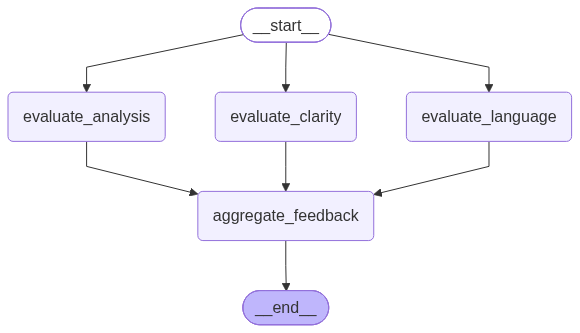

In [29]:
workflow

In [30]:
essay = """
Technology has become an inseparable part of modern life. It has revolutionized communication, transformed industries, and changed the way people learn, work, and interact. In a rapidly globalizing world, technology is not merely a tool; it is a force that shapes economies, politics, and social relationships. However, while technological progress has brought immense convenience and opportunity, it has also created new challenges such as digital inequality, data privacy concerns, and the erosion of human values. The real question is not whether technology should be embraced, but how it should be guided so that it serves humanity rather than overwhelms it.

One of the most significant contributions of technology is its ability to expand access to information. Digital platforms, online education, telemedicine, and e-governance have made services more accessible, especially to people in remote and underserved regions. Students can now access world-class knowledge without leaving their homes, farmers can use digital tools for better crop management, and citizens can interact with government institutions more efficiently. Such innovations have democratized information and have the potential to reduce disparities if used equitably. Yet, technology also reflects the inequalities of society. Those without internet access, digital literacy, or financial resources are left behind, widening the gap between the privileged and the marginalized.

The rise of artificial intelligence and automation has further intensified the debate around technology and employment. While automation improves productivity and reduces repetitive tasks, it also threatens jobs in sectors that rely on routine labor. This creates a need for reskilling and lifelong learning. Education systems must adapt to equip individuals with creativity, critical thinking, emotional intelligence, and technological fluency. The future workforce will not be defined only by technical skills, but also by the ability to think ethically, adapt quickly, and solve complex problems. In this sense, technology should be seen as a complement to human capability, not a replacement for it.

Another concern is the impact of technology on human relationships and social life. Social media, for instance, has connected people across distances, but it has also reduced face-to-face communication, fostered misinformation, and amplified polarization. People often curate idealized versions of themselves online, leading to anxiety, comparison, and emotional distress. Technology, when left unregulated, can distort public discourse and weaken trust in institutions. A balanced use of technology therefore requires digital ethics, media literacy, and responsible governance.

Ultimately, technology is neither inherently good nor bad; its moral worth depends on how societies choose to use it. Governments, institutions, and individuals must work together to ensure that innovation is inclusive, ethical, and sustainable. Policies should protect privacy, encourage digital access, and regulate harmful practices. At the same time, education must cultivate values such as empathy, responsibility, and democratic citizenship. Only then can technology become a bridge to human progress instead of a source of fragmentation and inequality.

The challenge before humanity is not to reject technology, but to master it with wisdom. Progress must be measured not just by efficiency or profit, but by dignity, equality, and human well-being. If technology is designed and used in service of these values, it can become one of the greatest instruments for building a more just and enlightened society.
"""

# To use this in the workflow:
# initial_state = {'essay': upsc_essay}
# workflow.invoke(initial_state)

In [33]:
initial_state = {
    'essay': essay
}

workflow.invoke(initial_state)


{'essay': '\nTechnology has become an inseparable part of modern life. It has revolutionized communication, transformed industries, and changed the way people learn, work, and interact. In a rapidly globalizing world, technology is not merely a tool; it is a force that shapes economies, politics, and social relationships. However, while technological progress has brought immense convenience and opportunity, it has also created new challenges such as digital inequality, data privacy concerns, and the erosion of human values. The real question is not whether technology should be embraced, but how it should be guided so that it serves humanity rather than overwhelms it.\n\nOne of the most significant contributions of technology is its ability to expand access to information. Digital platforms, online education, telemedicine, and e-governance have made services more accessible, especially to people in remote and underserved regions. Students can now access world-class knowledge without lea